In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import glob

# Set aesthetic styling parameters for report figures
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.max_open_warning': 0, 'font.size': 11})

# Detect the uploaded Melbourne Housing CSV file
csv_files = glob.glob('MELBOURNE_HOUSE_PRICES_*.csv') + glob.glob('melb_data.csv')
file_path = csv_files[0] if csv_files else 'MELBOURNE_HOUSE_PRICES_LESS.csv'

try:
    df = pd.read_csv(file_path)
    print(f"Loaded file: {file_path}")
    print(f"Total Instances (Rows): {df.shape[0]} | Total Features (Columns): {df.shape[1]}")
    display(df.head(3))
except FileNotFoundError:
    print(f"Could not automatically find the dataset file. Please make sure '{file_path}' or a similar CSV is uploaded to your Colab session.")

Loaded file: MELBOURNE_HOUSE_PRICES_LESS.csv
Total Instances (Rows): 63023 | Total Features (Columns): 13


,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Postcode,Regionname,Propertycount,Distance,CouncilArea
0,Abbotsford,49 Lithgow St,3,h,1490000.0,S,Jellis,1/04/2017,3067,Northern Metropolitan,4019,3.0,Yarra City Council
1,Abbotsford,59A Turner St,3,h,1220000.0,S,Marshall,1/04/2017,3067,Northern Metropolitan,4019,3.0,Yarra City Council
2,Abbotsford,119B Yarra St,3,h,1420000.0,S,Nelson,1/04/2017,3067,Northern Metropolitan,4019,3.0,Yarra City Council


### 1. Missing Values Investigation (Task 3)


=== TABLE 1: MISSING VALUES SUMMARY ===


,Data Type,Missing Count,Missing (%)
Price,float64,14590,23.150278


/tmp/ipykernel_971/684789583.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_plot_data.index, y=missing_plot_data['Missing (%)'], palette='Reds_r')


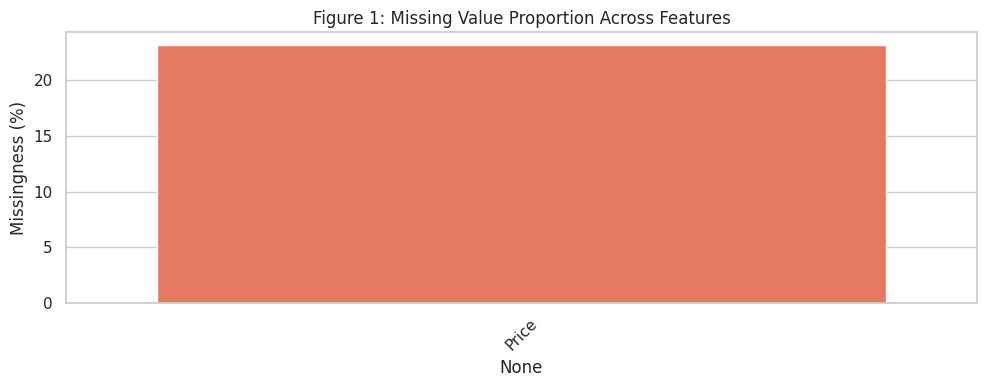

In [ ]:
# Missing values summary table
missing_df = pd.DataFrame({
    'Data Type': df.dtypes,
    'Missing Count': df.isnull().sum(),
    'Missing (%)': (df.isnull().sum() / len(df)) * 100
}).sort_values(by='Missing Count', ascending=False)

print("=== TABLE 1: MISSING VALUES SUMMARY ===")
display(missing_df[missing_df['Missing Count'] > 0])

# Missingness visualization
plt.figure(figsize=(10, 4))
missing_plot_data = missing_df[missing_df['Missing (%)'] > 0]
if not missing_plot_data.empty:
    sns.barplot(x=missing_plot_data.index, y=missing_plot_data['Missing (%)'], palette='Reds_r')
    plt.title('Figure 1: Missing Value Proportion Across Features')
    plt.ylabel('Missingness (%)')
    plt.xticks(rotation=45)
else:
    plt.text(0.5, 0.5, 'No Missing Values Detected', ha='center', va='center')
plt.tight_layout()
plt.show()

### 2. Duplicate Records Verification (Task 3)


In [ ]:
total_exact_duplicates = df.duplicated().sum()
duplicate_percentage = (total_exact_duplicates / len(df)) * 100

duplicate_summary = pd.DataFrame({
    'Metric': ['Total Instances', 'Exact Duplicate Rows', 'Duplicate Ratio (%)'],
    'Value': [len(df), total_exact_duplicates, round(duplicate_percentage, 4)]
})

print("=== TABLE 2: DUPLICATE RECORDS AUDIT ===")
display(duplicate_summary)

if total_exact_duplicates > 0:
    print("\nSample Duplicate Records:")
    display(df[df.duplicated(keep=False)].head(4))

=== TABLE 2: DUPLICATE RECORDS AUDIT ===


,Metric,Value
0,Total Instances,63023.0000
1,Exact Duplicate Rows,2.0000
2,Duplicate Ratio (%),0.0032



Sample Duplicate Records:


,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Postcode,Regionname,Propertycount,Distance,CouncilArea
8041,Fitzroy North,5/16 Taplin St,2,h,1010000.0,SP,Woodards,5/05/2018,3068,Northern Metropolitan,6244,3.6,Moreland City Council
8042,Fitzroy North,5/16 Taplin St,2,h,1010000.0,SP,Woodards,5/05/2018,3068,Northern Metropolitan,6244,3.6,Moreland City Council
33941,Nunawading,1/7 Lilian St,3,t,NaN,SP,Jellis,17/06/2017,3131,Eastern Metropolitan,4973,15.4,Manningham City Council
33942,Nunawading,1/7 Lilian St,3,t,NaN,SP,Jellis,17/06/2017,3131,Eastern Metropolitan,4973,15.4,Manningham City Council


### 3. Outlier Analysis - Tukey's IQR Method (Task 3)


=== TABLE 3: TUKEY IQR OUTLIER DETECTION ===


,Feature,Q1 (25%),Q3 (75%),IQR,Lower Bound,Upper Bound,Outlier Count,Outlier (%)
0,Rooms,3.0,4.0,1.0,1.50,5.50,2644,4.20
2,Postcode,3056.0,3163.0,107.0,2895.50,3323.50,2382,3.78
1,Price,620000.0,1220000.0,600000.0,-280000.00,2120000.00,2272,4.69
4,Distance,7.0,16.7,9.7,-7.55,31.25,1996,3.17
3,Propertycount,4380.0,10412.0,6032.0,-4668.00,19460.00,1241,1.97


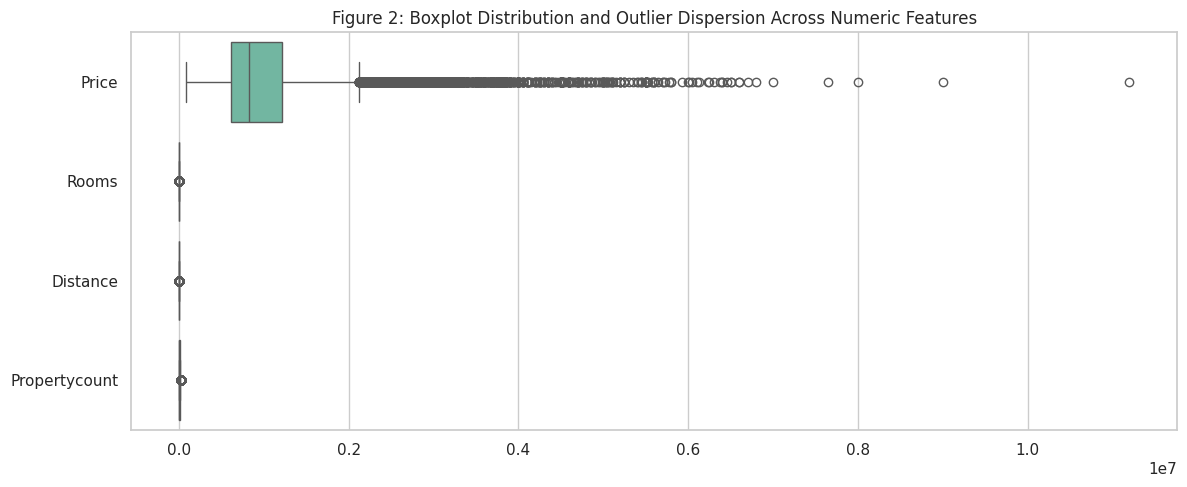

In [ ]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

outlier_rows = []
for col in numeric_cols:
    data_col = df[col].dropna()
    if len(data_col) == 0:
        continue
    q1 = data_col.quantile(0.25)
    q3 = data_col.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = data_col[(data_col < lower_bound) | (data_col > upper_bound)]
    outlier_rows.append({
        'Feature': col,
        'Q1 (25%)': round(q1, 2),
        'Q3 (75%)': round(q3, 2),
        'IQR': round(iqr, 2),
        'Lower Bound': round(lower_bound, 2),
        'Upper Bound': round(upper_bound, 2),
        'Outlier Count': len(outliers),
        'Outlier (%)': round((len(outliers) / len(data_col)) * 100, 2)
    })

outlier_table = pd.DataFrame(outlier_rows).sort_values(by='Outlier Count', ascending=False)
print("=== TABLE 3: TUKEY IQR OUTLIER DETECTION ===")
display(outlier_table)

features_to_plot = [c for c in ['Price', 'Rooms', 'Distance', 'Landsize', 'Propertycount'] if c in df.columns]
if features_to_plot:
    plt.figure(figsize=(12, 5))
    sns.boxplot(data=df[features_to_plot], orient='h', palette='Set2')
    plt.title('Figure 2: Boxplot Distribution and Outlier Dispersion Across Numeric Features')
    plt.tight_layout()
    plt.show()

### 4. Feature Distributions Analysis (Task 3)


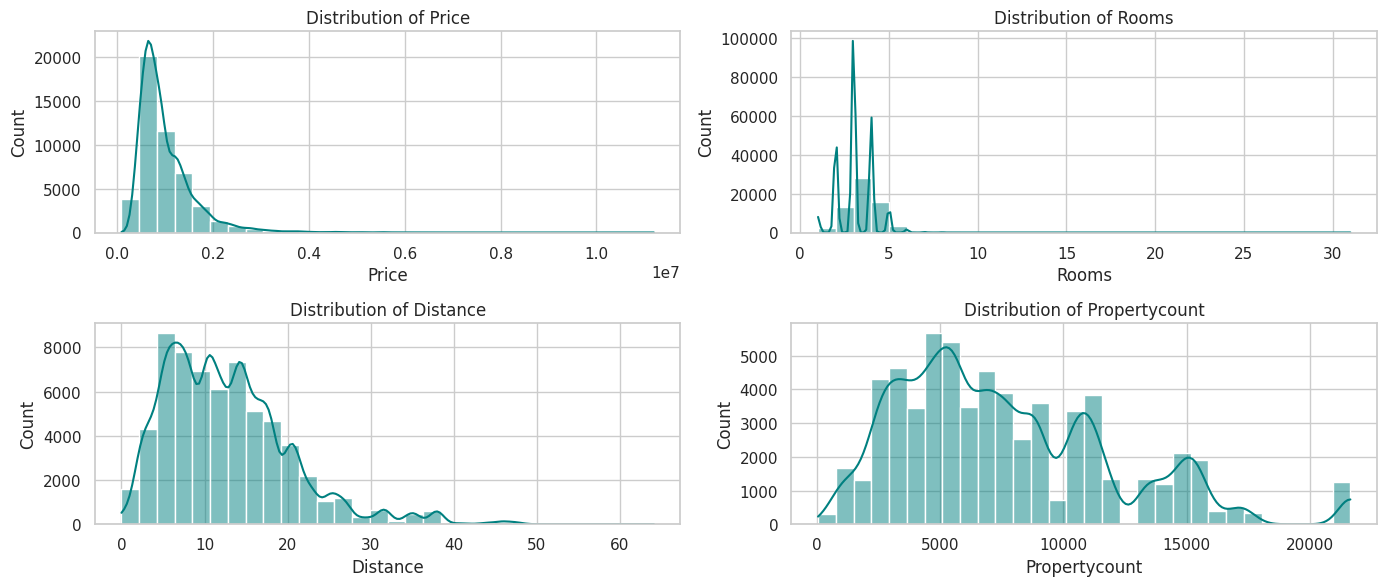

In [ ]:
dist_cols = [c for c in ['Price', 'Rooms', 'Distance', 'Propertycount'] if c in df.columns]

if dist_cols:
    plt.figure(figsize=(14, 6))
    for i, col in enumerate(dist_cols, 1):
        plt.subplot(2, 2, i)
        sns.histplot(df[col].dropna(), kde=True, bins=30, color='teal')
        plt.title(f'Distribution of {col}')
        plt.xlabel(col)
    plt.tight_layout()
    plt.show()

### 5. Skewness & Kurtosis Evaluation (Task 3)


=== TABLE 4: SKEWNESS & KURTOSIS COEFFICIENTS ===


,Mean,Median,Std Dev,Skewness,Kurtosis
Rooms,3.111,3.0,0.958,0.793,13.213
Price,997898.241,830000.0,593498.919,2.650,13.597
Postcode,3125.674,3107.0,125.627,3.815,18.142
Propertycount,7617.728,6795.0,4424.423,0.902,0.553
Distance,12.685,11.4,7.592,1.152,2.012


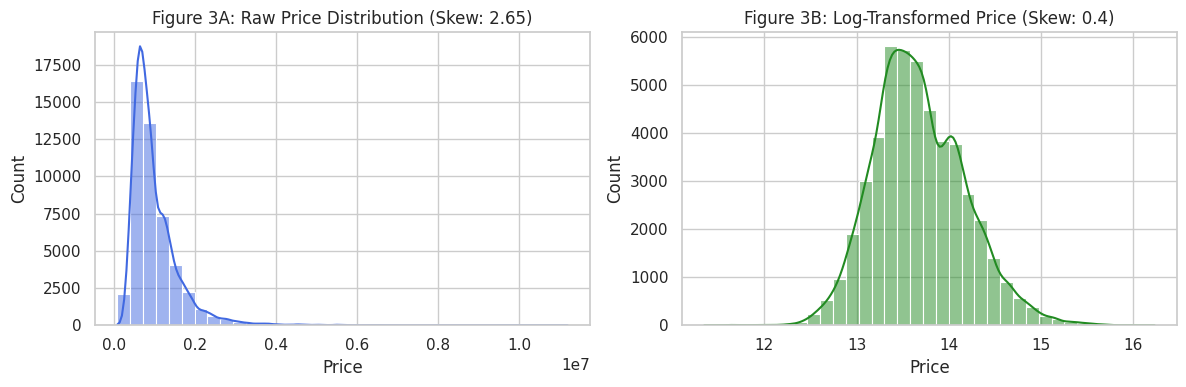

In [ ]:
skew_kurt_summary = pd.DataFrame({
    'Mean': df[numeric_cols].mean(),
    'Median': df[numeric_cols].median(),
    'Std Dev': df[numeric_cols].std(),
    'Skewness': df[numeric_cols].apply(lambda x: stats.skew(x.dropna())),
    'Kurtosis': df[numeric_cols].apply(lambda x: stats.kurtosis(x.dropna()))
})

print("=== TABLE 4: SKEWNESS & KURTOSIS COEFFICIENTS ===")
display(skew_kurt_summary.round(3))

if 'Price' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(df['Price'].dropna(), kde=True, ax=axes[0], color='royalblue', bins=35)
    axes[0].set_title(f"Figure 3A: Raw Price Distribution (Skew: {round(stats.skew(df['Price'].dropna()), 2)})")

    sns.histplot(np.log1p(df['Price'].dropna()), kde=True, ax=axes[1], color='forestgreen', bins=35)
    axes[1].set_title(f"Figure 3B: Log-Transformed Price (Skew: {round(stats.skew(np.log1p(df['Price'].dropna())), 2)})")
    plt.tight_layout()
    plt.show()

### 6. Correlation Analysis & Multicollinearity Check (Task 3)


=== TABLE 5: PEARSON CORRELATION MATRIX ===


,Rooms,Price,Postcode,Propertycount,Distance
Rooms,1.000,0.412,0.094,-0.049,0.268
Price,0.412,1.000,0.003,-0.061,-0.254
Postcode,0.094,0.003,1.000,-0.003,0.500
Propertycount,-0.049,-0.061,-0.003,1.000,0.014
Distance,0.268,-0.254,0.500,0.014,1.000


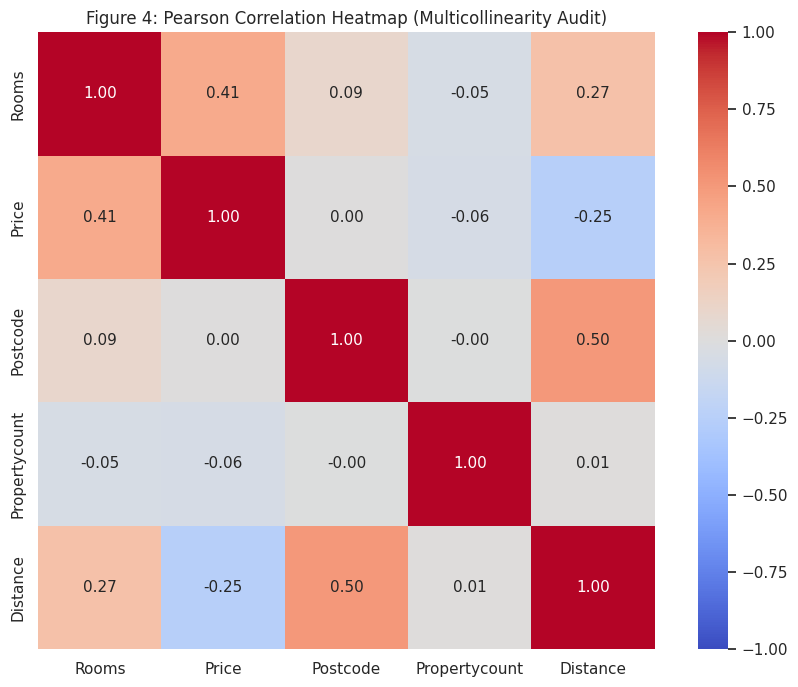

In [ ]:
corr_matrix = df[numeric_cols].corr()

print("=== TABLE 5: PEARSON CORRELATION MATRIX ===")
display(corr_matrix.round(3))

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, square=True)
plt.title("Figure 4: Pearson Correlation Heatmap (Multicollinearity Audit)")
plt.tight_layout()
plt.show()

### 7. Categorical Imbalance Analysis (Task 3)


/tmp/ipykernel_971/1960501190.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=order, palette='viridis')
/tmp/ipykernel_971/1960501190.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=order, palette='viridis')
/tmp/ipykernel_971/1960501190.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=order, palette='viridis')


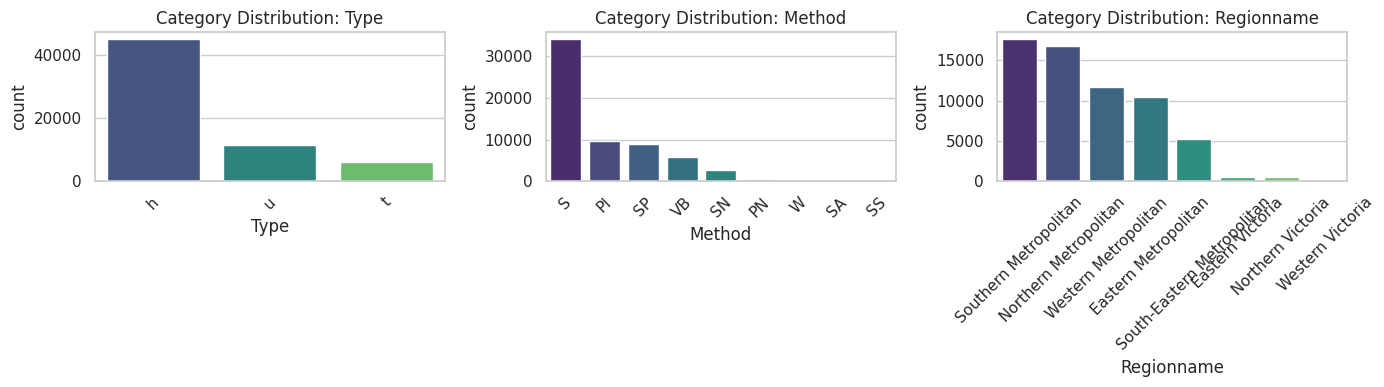

=== TABLE 6: CATEGORICAL FREQUENCY DISTRIBUTIONS ===


,Count,Percentage (%)
Type,,
h,45053,71.49
u,11655,18.49
t,6315,10.02


,Count,Percentage (%)
Method,,
S,34063,54.05
PI,9790,15.53
SP,8916,14.15
VB,5956,9.45
SN,2674,4.24
PN,651,1.03
W,484,0.77
SA,416,0.66
SS,73,0.12


In [ ]:
categorical_targets = [c for c in ['Type', 'Method', 'Regionname'] if c in df.columns]

if categorical_targets:
    plt.figure(figsize=(14, 4))
    for i, col in enumerate(categorical_targets[:3], 1):
        plt.subplot(1, 3, i)
        order = df[col].value_counts().index
        sns.countplot(data=df, x=col, order=order, palette='viridis')
        plt.title(f'Category Distribution: {col}')
        plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

print("=== TABLE 6: CATEGORICAL FREQUENCY DISTRIBUTIONS ===")
for col in categorical_targets[:2]:
    counts = df[col].value_counts()
    percentages = df[col].value_counts(normalize=True) * 100
    display(pd.DataFrame({'Count': counts, 'Percentage (%)': percentages.round(2)}))

### 8. Noise & High Cardinality Feature Identification (Task 3)


In [ ]:
cardinality_data = []
for col in df.columns:
    n_unique = df[col].nunique()
    uniqueness_ratio = (n_unique / len(df)) * 100
    cardinality_data.append({
        'Feature': col,
        'Data Type': str(df[col].dtype),
        'Unique Values': n_unique,
        'Uniqueness Ratio (%)': round(uniqueness_ratio, 2),
        'Noise Risk': 'High (Risk of Overfitting)' if uniqueness_ratio > 30 and df[col].dtype == 'object' else 'Normal'
    })

noise_table = pd.DataFrame(cardinality_data).sort_values(by='Unique Values', ascending=False)
print("=== TABLE 7: NOISE & CARDINALITY AUDIT ===")
display(noise_table)

=== TABLE 7: NOISE & CARDINALITY AUDIT ===


,Feature,Data Type,Unique Values,Uniqueness Ratio (%),Noise Risk
1,Address,object,57754,91.64,High (Risk of Overfitting)
4,Price,float64,3417,5.42,Normal
6,SellerG,object,476,0.76,Normal
0,Suburb,object,380,0.60,Normal
10,Propertycount,int64,368,0.58,Normal
8,Postcode,int64,225,0.36,Normal
11,Distance,float64,180,0.29,Normal
7,Date,object,112,0.18,Normal
12,CouncilArea,object,34,0.05,Normal
2,Rooms,int64,14,0.02,Normal


### 9. Categorical Formatting & Data Inconsistency Audit (Task 3)


In [ ]:
string_cols = df.select_dtypes(include=['object']).columns.tolist()

inconsistency_audit = []
for col in string_cols:
    raw_unique = df[col].dropna().nunique()
    stripped_lower_unique = df[col].dropna().astype(str).str.strip().str.lower().nunique()
    discrepancy = raw_unique - stripped_lower_unique
    inconsistency_audit.append({
        'Feature': col,
        'Raw Unique Levels': raw_unique,
        'Standardised Levels': stripped_lower_unique,
        'Inconsistency Discrepancies': discrepancy,
        'Status': 'Formatting Inconsistency' if discrepancy > 0 else 'Uniform / Clean'
    })

inconsistency_table = pd.DataFrame(inconsistency_audit)
print("=== TABLE 8: CATEGORICAL INCONSISTENCY AUDIT ===")
display(inconsistency_table)

=== TABLE 8: CATEGORICAL INCONSISTENCY AUDIT ===


,Feature,Raw Unique Levels,Standardised Levels,Inconsistency Discrepancies,Status
0,Suburb,380,377,3,Formatting Inconsistency
1,Address,57754,57731,23,Formatting Inconsistency
2,Type,3,3,0,Uniform / Clean
3,Method,9,9,0,Uniform / Clean
4,SellerG,476,470,6,Formatting Inconsistency
5,Date,112,112,0,Uniform / Clean
6,Regionname,8,8,0,Uniform / Clean
7,CouncilArea,34,34,0,Uniform / Clean


### 10. Data Preprocessing Pipeline Implementation (Task 4)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler

# 1. Target Filtering: Drop records with missing targets
if 'Price' in df.columns:
    df_cleaned = df.dropna(subset=['Price']).copy()

    # 2. Feature Pruning: Drop redundant/collinear columns and granular text identifiers
    drop_cols = ['Address', 'Date', 'Postcode', 'Bedroom2', 'SellerG']
    df_cleaned = df_cleaned.drop(columns=[c for c in drop_cols if c in df_cleaned.columns])

    # Separate Target and Predictors
    X = df_cleaned.drop(columns=['Price'])
    y = np.log1p(df_cleaned['Price'])

    # Categorize remaining features
    categorical_cols = [c for c in ['Type', 'Method', 'Regionname'] if c in X.columns]
    numerical_cols = X.select_dtypes(include=[np.number]).columns.tolist()

    # 3. Build Modular Preprocessing Transformers
    num_pipeline = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', RobustScaler())
    ])

    cat_pipeline = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])

    preprocessor = ColumnTransformer(transformers=[
        ('num', num_pipeline, numerical_cols),
        ('cat', cat_pipeline, categorical_cols)
    ])

    # 4. Train-Test Partitioning
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    X_train_transformed = preprocessor.fit_transform(X_train)
    X_test_transformed = preprocessor.transform(X_test)

    print("=== PIPELINE EXECUTION SUMMARY ===")
    print(f"Original Training Features: {X_train.shape[1]} columns")
    print(f"Processed Training Matrix:  {X_train_transformed.shape[0]} rows, {X_train_transformed.shape[1]} columns")
    print(f"Processed Test Matrix:      {X_test_transformed.shape[0]} rows, {X_test_transformed.shape[1]} columns")
else:
    print("Target variable 'Price' not found in dataset. Skipping preprocessing pipeline setup.")

=== PIPELINE EXECUTION SUMMARY ===
Original Training Features: 8 columns
Processed Training Matrix:  38746 rows, 19 columns
Processed Test Matrix:      9687 rows, 19 columns
